In [3]:
# Testing your installation
import tensorflow as tf
from tensorflow import keras
import numpy as np

print('TensorFlow: ', tf.__version__)
print('Keras', keras.__version__)


TensorFlow:  2.19.0
Keras 3.10.0


In [4]:
f_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = f_mnist.load_data()
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('X data type: ', X_train.dtype)
print('y_train shape: ', y_train.shape)


X_train shape:  (60000, 28, 28)
X_test shape:  (10000, 28, 28)
X data type:  uint8
y_train shape:  (60000,)


In [5]:
# y_train  = to_categorical(y_train)
# y_test   = to_categorical(y_test)

In [10]:
X_train[1].shape

(28, 28)

In [11]:
X_train[1][0].shape

(28,)

## Preparing the image data

Before training, we’ll preprocess the data by:

1. Scaling it (as we will use the Gradient Descent to train our network) so that all values are in the [0, 1] interval.
2. Training images, for instance, were stored in an array of shape (60000, 28, 28) of type uint8 with values in the [0, 255] interval per pixel. We will transform it into a float32 array of shape (60000, 28 * 28) with values between 0 and 1.

dataset [link](https://github.com/zalandoresearch/fashion-mnist)

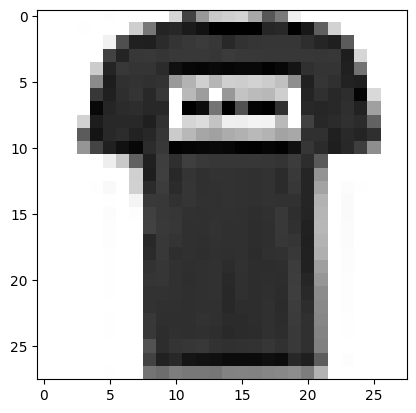

[[  0   0   0   0   0   1   0   0   0   0  41 188 103  54  48  43  87 168 133  16   0   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0  49 136 219 216 228 236 255 255 255 255 217 215 254 231 160  45   0   0   0   0   0]
 [  0   0   0   0   0  14 176 222 224 212 203 198 196 200 215 204 202 201 201 201 209 218 224 164   0   0   0   0]
 [  0   0   0   0   0 188 219 200 198 202 198 199 199 201 196 198 198 200 200 200 200 201 200 225  41   0   0   0]
 [  0   0   0   0  51 219 199 203 203 212 238 248 250 245 249 246 247 252 248 235 207 203 203 222 140   0   0   0]
 [  0   0   0   0 116 226 206 204 207 204 101  75  47  73  48  50  45  51  63 113 222 202 206 220 224   0   0   0]
 [  0   0   0   0 200 222 209 203 215 200   0  70  98   0 103  59  68  71  49   0 219 206 214 210 250  38   0   0]
 [  0   0   0   0 247 218 212 210 215 214   0 254 243 139 255 174 251 255 205   0 215 217 214 208 220  95   0   0]
 [  0   0   0  45 226 214 214 215 224 205   0  42  35  60  16  17  12  13  70   

In [12]:
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=200)
plt.imshow(X_train[1], cmap=plt.cm.binary)
plt.show()
print(X_train[1])

In [13]:
X_train = X_train/255
# X_test = X_test/255

In [14]:
len(X_train[1])


28

In [15]:
class_name = np.array(["T-shirt/top", "Trouser", "Pullover",
                       "Dress", "Coat", "Sandal", "Shirt",
                       "Sneaker", "Bag", "Ankle boot"])

In [16]:
y_train[1], class_name[y_train[1]]

(np.uint8(0), np.str_('T-shirt/top'))

In [17]:
X_train[0].shape

(28, 28)

In [18]:
# 640 * 640

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from keras.models import Sequential
from tensorflow.keras import layers
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.optimizers import Adam

from keras.regularizers import l2


In [ ]:
# Create Sequential Model
model = Sequential()

model.add(Flatten(input_shape=X_train[0].shape, name='input'))

model.add(Dense(256, activation='relu', name='hidden_1'))

model.add(Dense(128, activation='relu', name='hidden_2'))

model.add(Dense(64, activation='relu', name='hidden_3'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax', name='output')) # mulit
# model.add(Dense(1, activation='sigmoid', name='output')) # binary
# model.add(Dense(1, activation='linear', name='output')) # binary

# # Compile Model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# # Train Model
# history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

c:\Users\mahmo\cq-editor\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Flatten)                 │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=input, built=True>,
 <Dense name=hidden_1, built=True>,
 <Dense name=hidden_2, built=True>,
 <Dense name=hidden_3, built=True>,
 <Dense name=output, built=True>]

In [23]:
hidden_1 = model.layers[1]
h1_weights, h1_bias = hidden_1.get_weights()
print(h1_weights.shape)
print(h1_bias.shape)

(784, 256)
(256,)


In [14]:
len(h1_weights[0])

256

In [25]:
h1_weights

array([[-0.0232645 ,  0.02885895, -0.05470107, ..., -0.01850263, -0.07200547,  0.00179102],
       [ 0.03065027,  0.03544565,  0.00813738, ...,  0.02873083,  0.06340353, -0.00994048],
       [ 0.03676043,  0.03881726, -0.07426386, ...,  0.03193694, -0.05926768, -0.02600275],
       ...,
       [ 0.05182205, -0.07003067,  0.03065982, ..., -0.04915211, -0.05899165, -0.03073682],
       [ 0.02817982,  0.03318901,  0.02025113, ...,  0.02905013, -0.0459047 ,  0.00891423],
       [ 0.00846197,  0.06024037, -0.04820953, ..., -0.00047455, -0.04304165, -0.05447398]], dtype=float32)

In [26]:
h1_bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
     

In [ ]:
# from tensorflow import keras
# opt = keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
[
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
]

[
    1,
    1,
    0,
    1,
    3,
    1,
    8,
    1,
]

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',# categorical_crossentropy  binary_crossentropy
            optimizer='adam',
            metrics=['accuracy', 'precision', 'recall', 'f1_score'])


In [ ]:
# y_test = to_categorical(y_test)
# y_train = to_categorical(y_train)

from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [ ]:
ReduceLROnPlateau()

In [ ]:
# Creat checkpoint to save model at the end of each epoch:
checkpoint_cb = ModelCheckpoint("my_keras_model.h5", save_best_only=True)

# Creat EarlyStopping checkpoint:
early_stopping_cb = EarlyStopping(patience=10, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(patience=10)

history = model.fit(X_train, y_train,
                    epochs=20, batch_size=32,
                    validation_split=5/60,
                    callbacks=[checkpoint_cb, early_stopping_cb, lr_cb]
                    ) # batch_size = 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

learning_data = pd.DataFrame(history.history)
learning_data.plot(figsize=(10,5))
plt.grid(True)
plt.show()

In [ ]:
model.evaluate(X_test/255, y_test)

In [ ]:
X_new = X_test[5].reshape(1,-1)
y_pred = model.predict(X_new)
y_pred


In [ ]:
print(X_test[5])


In [ ]:
plt.imshow(X_test[5], cmap=plt.cm.binary)
plt.show()

In [ ]:
[]

In [ ]:
y_pred = np.argmax(model.predict(X_new), axis=-1)
print('actual values', y_test[5])
print('predicted values', y_pred)
class_name[y_pred[:]]


In [ ]:
import numpy as np

np.argmax([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])


(np.int64(5), np.int64(0))